In [44]:
# Capstone Project: Default of Credit Card Clients Dataset
'This project analyzes factors affecting credit card default and builds a predictive model.'


'This project analyzes factors affecting credit card default and builds a predictive model.'

In [45]:
#IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [46]:
#LOAD THE DATASET
df = pd.read_csv("data/default_of_credit_card_clients.csv")
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [47]:
 #Basic Data Exploration (EDA)
'We check dataset dimensions, structure, basic statistics, and missing values.'


'We check dataset dimensions, structure, basic statistics, and missing values.'

In [48]:
df.shape


(30000, 25)

In [49]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [50]:
df.describe()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [51]:
df.isnull().sum()


ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [52]:
#DATA CLEANING
'We rename columns, remove duplicates, and convert categories.'
df.rename(columns={"default.payment.next.month": "default"}, inplace=True)
df.drop_duplicates(inplace=True)

df["SEX"] = df["SEX"].astype("category")
df["EDUCATION"] = df["EDUCATION"].astype("category")
df["MARRIAGE"] = df["MARRIAGE"].astype("category")



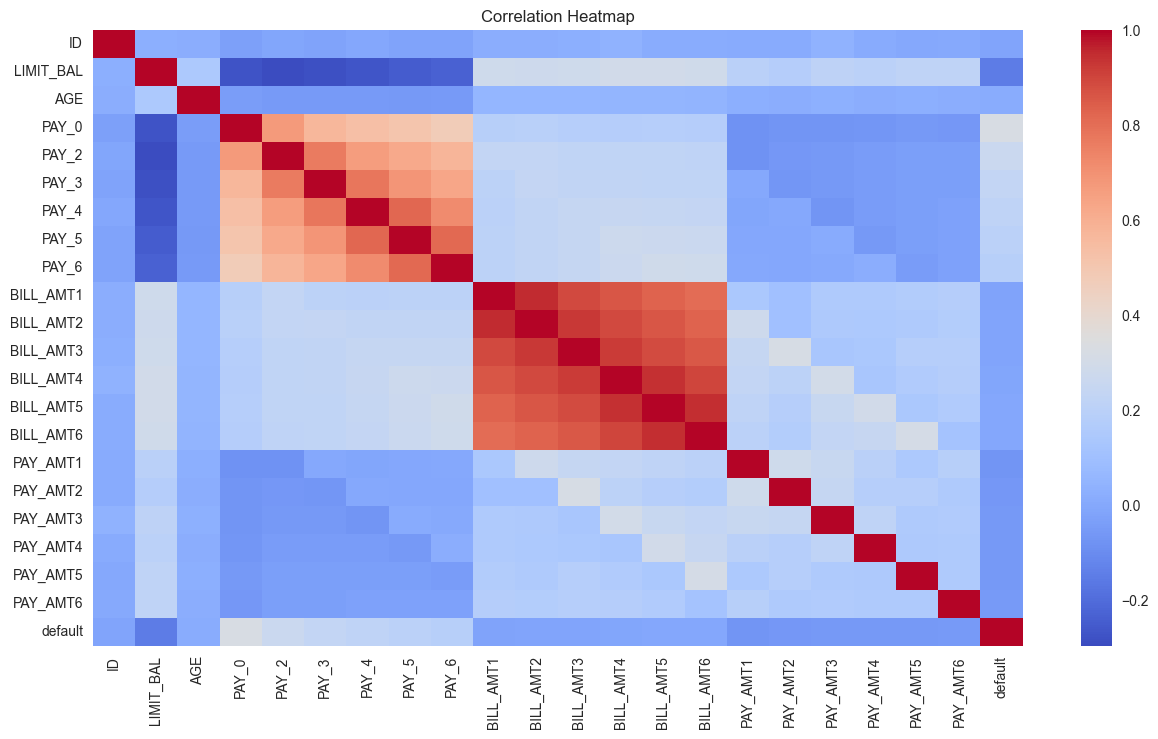

Accuracy: 0.8066666666666666
Top 10 Important Features:

PAY_0 : 0.6474915200827159
BILL_AMT1 : 0.4117790655836383
PAY_AMT2 : 0.23168282905850054
PAY_AMT1 : 0.2271216940663059
BILL_AMT3 : 0.14557821072737773
BILL_AMT2 : 0.11064735617495014
PAY_2 : 0.09778496503134967
PAY_3 : 0.09742837909854311
LIMIT_BAL : 0.09641893596377224
EDUCATION : 0.0957924422940935


In [53]:
#QUESTION 1 
"What features are most important for predicting default?"

#Code — Correlation Heatmap

plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#Code — Logistic Regression Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

#Code — Feature Importance

import numpy as np

importance = np.abs(model.coef_[0])
features = X.columns

sorted_idx = importance.argsort()[::-1]

print("Top 10 Important Features:\n")
for idx in sorted_idx[:10]:
    print(features[idx], ":", importance[idx])


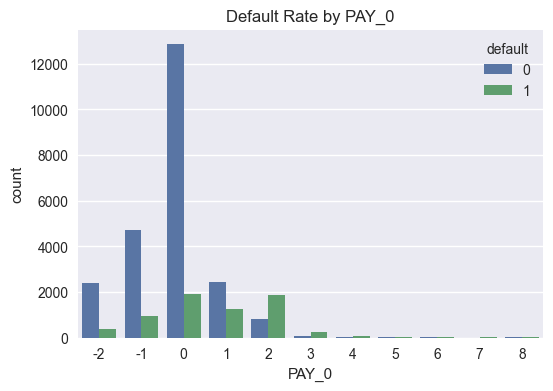

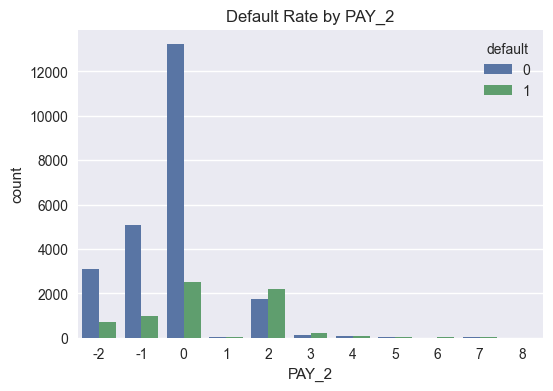

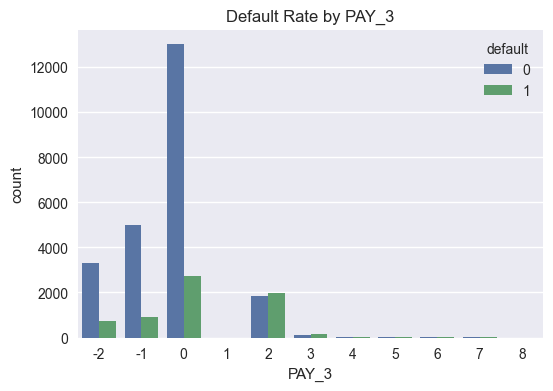

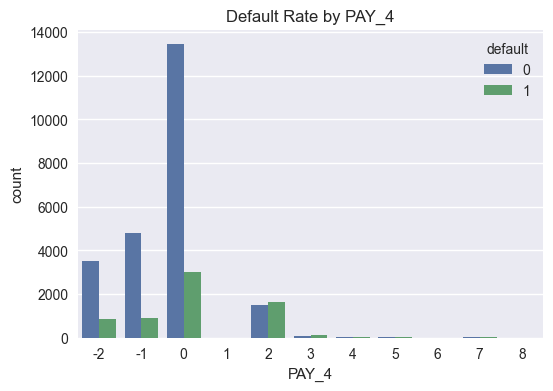

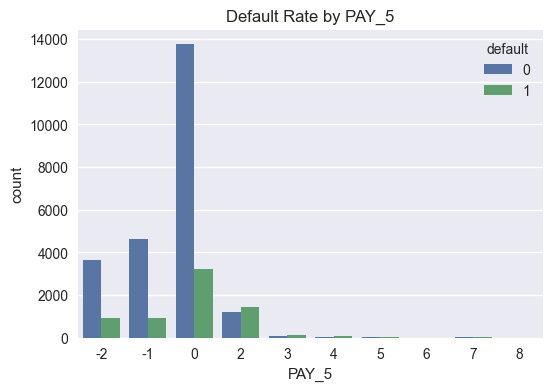

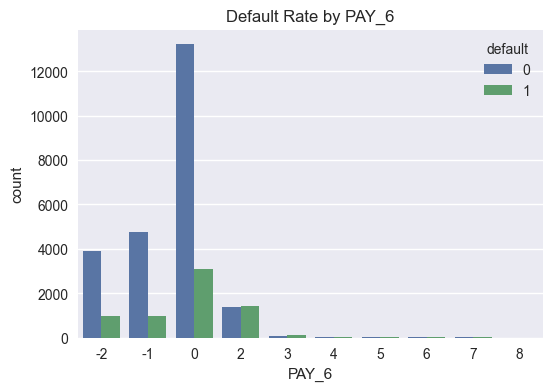

In [54]:
#QUESTION 2 — REPAYMENT HISTORY
"How do late payments (PAY_0 to PAY_6) affect default?"

pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

for col in pay_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], hue=df["default"])
    plt.title(f"Default Rate by {col}")
    plt.show()


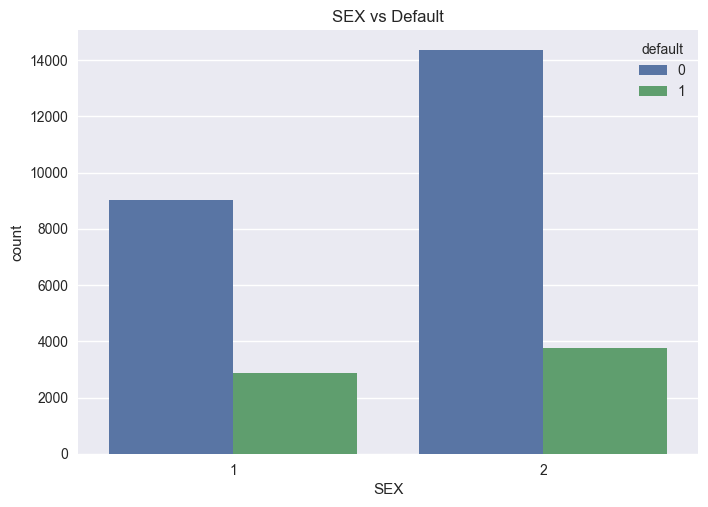

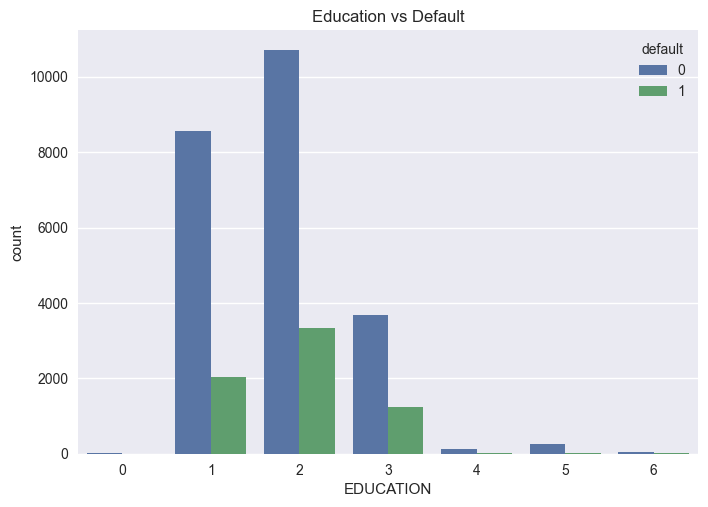

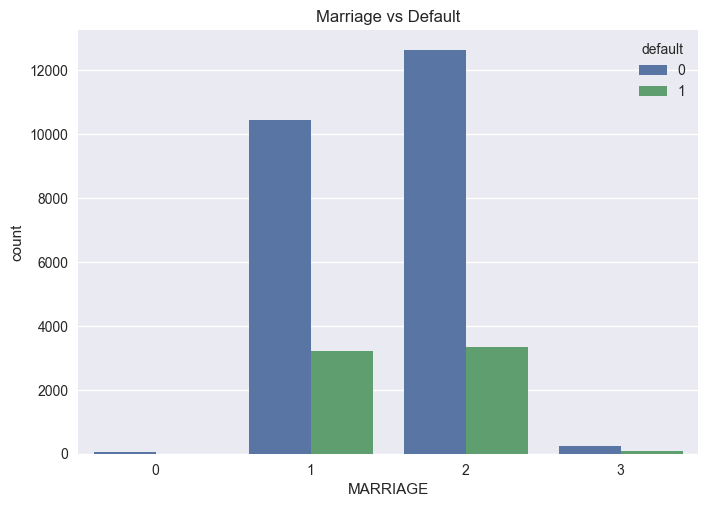

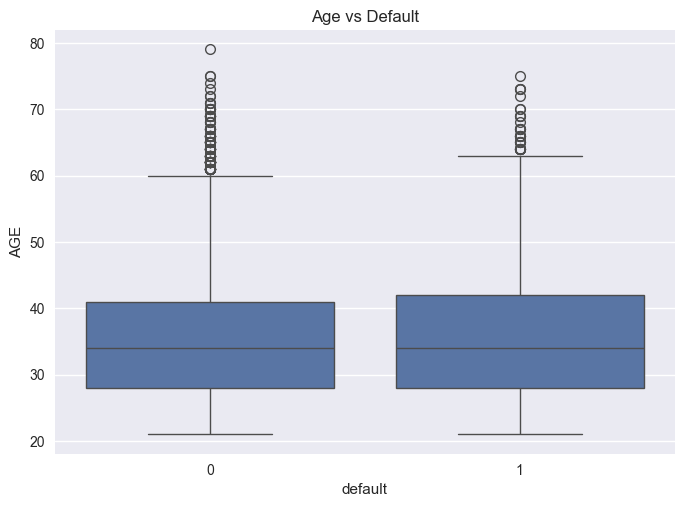

In [55]:
#QUESTION 3 — DEMOGRAPHICS
"How do demographic features affect default?"
sns.countplot(x="SEX", hue="default", data=df)
plt.title("SEX vs Default")
plt.show()

sns.countplot(x="EDUCATION", hue="default", data=df)
plt.title("Education vs Default")
plt.show()

sns.countplot(x="MARRIAGE", hue="default", data=df)
plt.title("Marriage vs Default")
plt.show()

sns.boxplot(x="default", y="AGE", data=df)
plt.title("Age vs Default")
plt.show()


In [56]:
#Question 4 Bill/Payment Dynamics and Debt Spiral


'We check whether clients with increasing bill amounts (BILL_AMT1–BILL_AMT6) and low or irregular payment amounts (PAY_AMT1–PAY_AMT6) are more likely to default.'


'We check whether clients with increasing bill amounts (BILL_AMT1–BILL_AMT6) and low or irregular payment amounts (PAY_AMT1–PAY_AMT6) are more likely to default.'

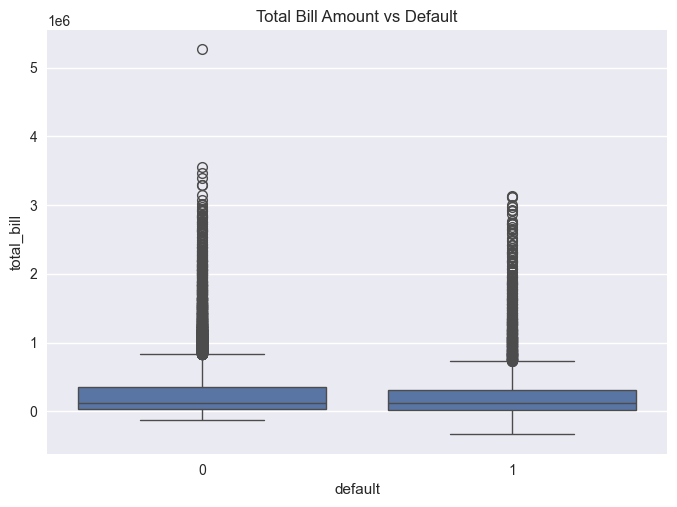

In [57]:
#Total Bill Amount vs Default

'This graph shows whether people with higher total bills default more.'

bill_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]

df["total_bill"] = df[bill_cols].sum(axis=1)

sns.boxplot(x="default", y="total_bill", data=df)
plt.title("Total Bill Amount vs Default")
plt.show()


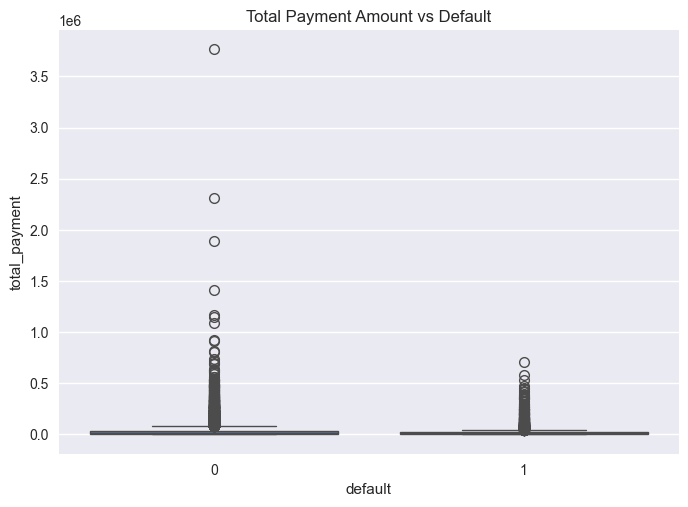

In [58]:
#Total Payment Amount vs Default

'This shows if people with low payments default more.'

pay_amt_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]

df["total_payment"] = df[pay_amt_cols].sum(axis=1)

sns.boxplot(x="default", y="total_payment", data=df)
plt.title("Total Payment Amount vs Default")
plt.show()


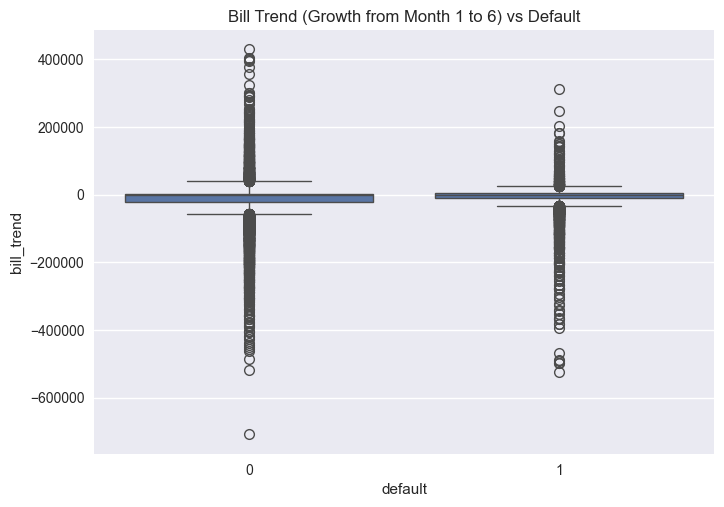

In [59]:
# Bill Growth (6 Months Trend)

'This checks if bills increased from month 1 to month 6.'

df["bill_trend"] = df["BILL_AMT6"] - df["BILL_AMT1"]

sns.boxplot(x="default", y="bill_trend", data=df)
plt.title("Bill Trend (Growth from Month 1 to 6) vs Default")
plt.show()


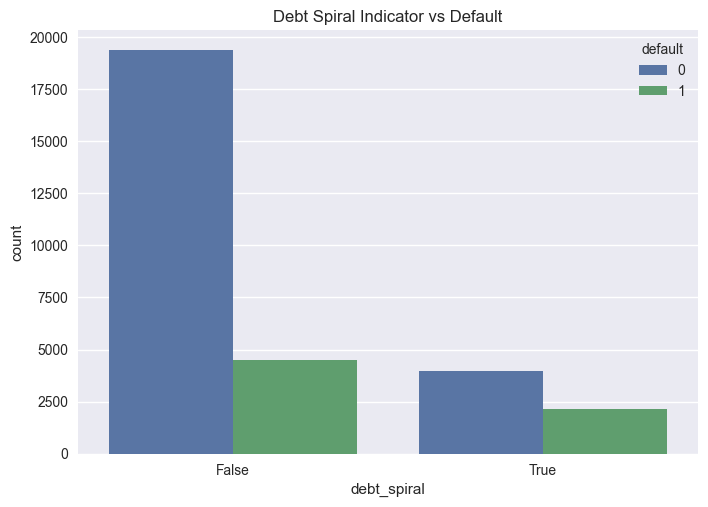

In [60]:
#Debt Spiral Indicator

'''This identifies customers who:

✔ Bill increased
✔ Payments are low

These are the highest-risk customers.'''

df["debt_spiral"] = (df["bill_trend"] > 0) & (df["total_payment"] < df["total_bill"] * 0.2)

sns.countplot(x=df["debt_spiral"], hue=df["default"])
plt.title("Debt Spiral Indicator vs Default")
plt.show()


In [ ]:
# Machine Learning Models: We now apply ML algorithms to predict customer default risk


In [61]:
#Install Package
'pip install xgboost'


'pip install xgboost'

In [62]:
#Imports

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [63]:
df = df.astype(float)


In [64]:
#Prepare Data
X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [65]:
# Convert category columns into numbers for XGBoost
df["SEX"] = df["SEX"].astype(int)
df["EDUCATION"] = df["EDUCATION"].astype(int)
df["MARRIAGE"] = df["MARRIAGE"].astype(int)


In [66]:
# Train Model

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [67]:
#Predictions + Accuracy
y_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


XGBoost Accuracy: 0.8238333333333333

Confusion Matrix:
 [[4447  240]
 [ 817  496]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.95      0.89      4687
         1.0       0.67      0.38      0.48      1313

    accuracy                           0.82      6000
   macro avg       0.76      0.66      0.69      6000
weighted avg       0.81      0.82      0.80      6000



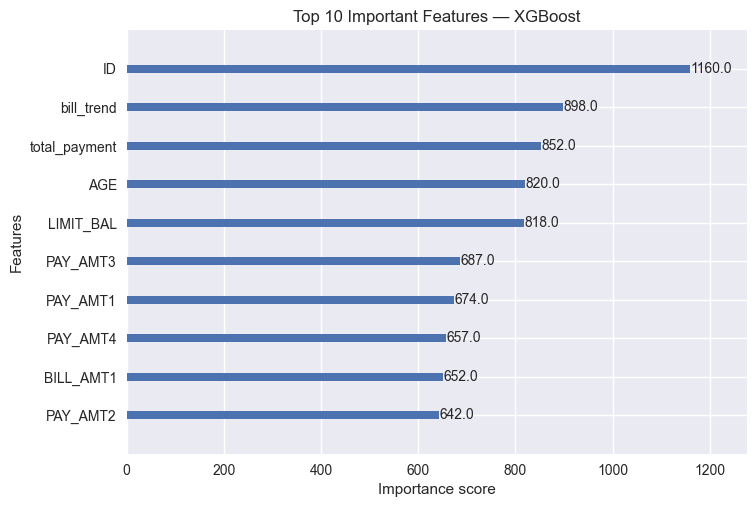

In [68]:
#Feature Importance Graph
xgb.plot_importance(xgb_model, max_num_features=10)
plt.title("Top 10 Important Features — XGBoost")
plt.show()
